In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

In [2]:
data = pd.read_csv(r'C:\Users\lucas\Desktop\3rd Semester\02806 - Social data and Visualization\02806_social_data_code\02806_social_data_analysis_group50\assignment1\merged_crime_data.csv')
data.head()

,Incident Category,Incident Description,Police District,Incident Date,Incident Time,Incident Day of Week,Longitude,Latitude,Incident Year
0,Motor Vehicle Theft,Stolen Automobile,Taraval,2016/03/03,19:30,Thursday,-122.463545,37.707968,2016
1,Motor Vehicle Theft,Stolen Truck,Mission,2014/12/26,15:30,Friday,-122.424435,37.755900,2014
2,Missing Person,Missing Adult,Park,2014/11/24,10:00,Monday,-122.437536,37.777844,2014
3,Missing Person,Missing Adult,Southern,2015/03/06,20:00,Friday,-122.396759,37.773173,2015
4,Larceny Theft,Grand Theft From Locked Auto,Southern,2005/10/21,10:15,Friday,-120.500000,90.000000,2005


In [3]:
data['Incident Date'] = pd.to_datetime(data['Incident Date'])

In [4]:
print(data['Incident Category'].unique())

['Motor Vehicle Theft' 'Missing Person' 'Larceny Theft' 'Arson' 'Robbery'
 'Vandalism' 'Weapon Laws' 'Burglary' 'Drug Violation' 'Stolen Property'
 'Forgery And Counterfeiting' 'Prostitution' 'Embezzlement']


# 1. Static Graph

In [5]:
# Create a heat map of crime incidents by day of the week and hour of the day

# Filter category + year (change these if you want a different crime)
df = data.copy()
# Build datetime from Date + Time
date_str = df["Incident Date"].astype(str).str.strip().str.replace("-", "/", regex=False)
time_str = df["Incident Time"].astype(str).str.strip()

df["dt"] = pd.to_datetime(date_str + " " + time_str, errors="coerce")
df = df.dropna(subset=["dt"])

# Make dt the index (this is key for time series)
df = df.set_index("dt").sort_index()

print("Rows:", len(df))
print("Index dtype:", df.index.dtype)

Rows: 1601737
Index dtype: datetime64[ns]


In [6]:
df_heat = df.copy()
df_heat["hour"] = df_heat.index.hour
df_heat["dow"] = df_heat.index.dayofweek  # Mon=0 ... Sun=6

In [7]:
heat = (
    df_heat.groupby(["dow", "hour"])
    .size()
    .unstack(fill_value=0)     # columns = hours, rows = dow
    .reindex(index=range(7), columns=range(24), fill_value=0)
)

heat.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

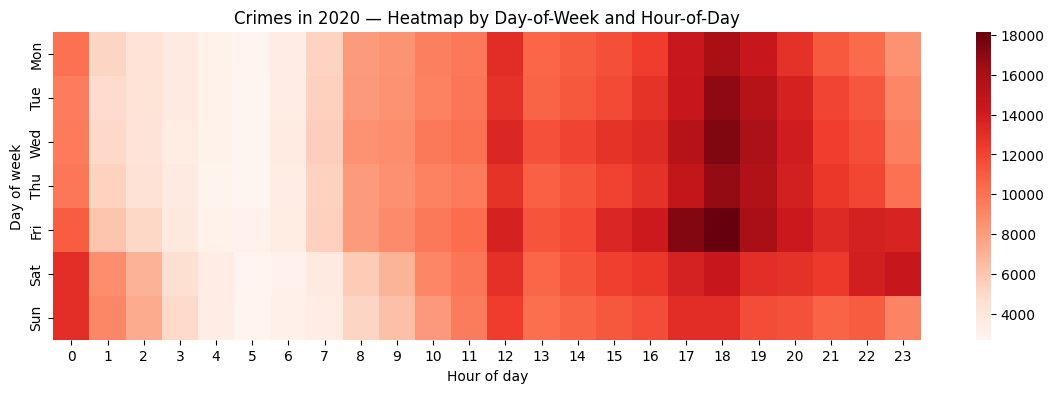

In [8]:
plt.figure(figsize=(14, 4))
sns.heatmap(heat, cmap="Reds")
plt.title("Crimes in 2020 — Heatmap by Day-of-Week and Hour-of-Day")
plt.xlabel("Hour of day")
plt.ylabel("Day of week")
plt.show()

In [6]:
# create dataset precovid dataset from march 2019 to february 2020 using incident date 
df_precovid = data[(data['Incident Date'] >= '2019-03-01') & (data['Incident Date'] < '2020-03-01')]
print(df_precovid.head())
# create dataset duringcovid dataset from march 2020 to february 2021 using incident date
df_duringcovid = data[(data['Incident Date'] >= '2020-03-01') & (data['Incident Date'] < '2021-03-01')]
print(df_duringcovid.head())
# Create dataset of postcovid
df_postcovid = data[(data['Incident Date'] >= '2021-03-01') & (data['Incident Date'] < '2022-03-01')]
print(df_postcovid.head())

        Incident Category                               Incident Description  \
1078969           Robbery                                  Robbery, W/ Force   
1082712      Embezzlement              Embezzlement, Grand Theft By Employee   
1084385     Larceny Theft  Embezzlement from Dependent or Elder Adult by ...   
1086232     Larceny Theft                           Theft, Grand, of Firearm   
1095305     Larceny Theft  Embezzlement from Dependent or Elder Adult by ...   

        Police District Incident Date Incident Time Incident Day of Week  \
1078969        Southern    2020-01-12         19:30               Sunday   
1082712      Tenderloin    2020-01-01         00:00            Wednesday   
1084385      Tenderloin    2020-01-01         00:00            Wednesday   
1086232        Southern    2019-12-03         19:00              Tuesday   
1095305            Park    2019-07-01         00:00               Monday   

          Longitude   Latitude  Incident Year  
1078969 -122.4

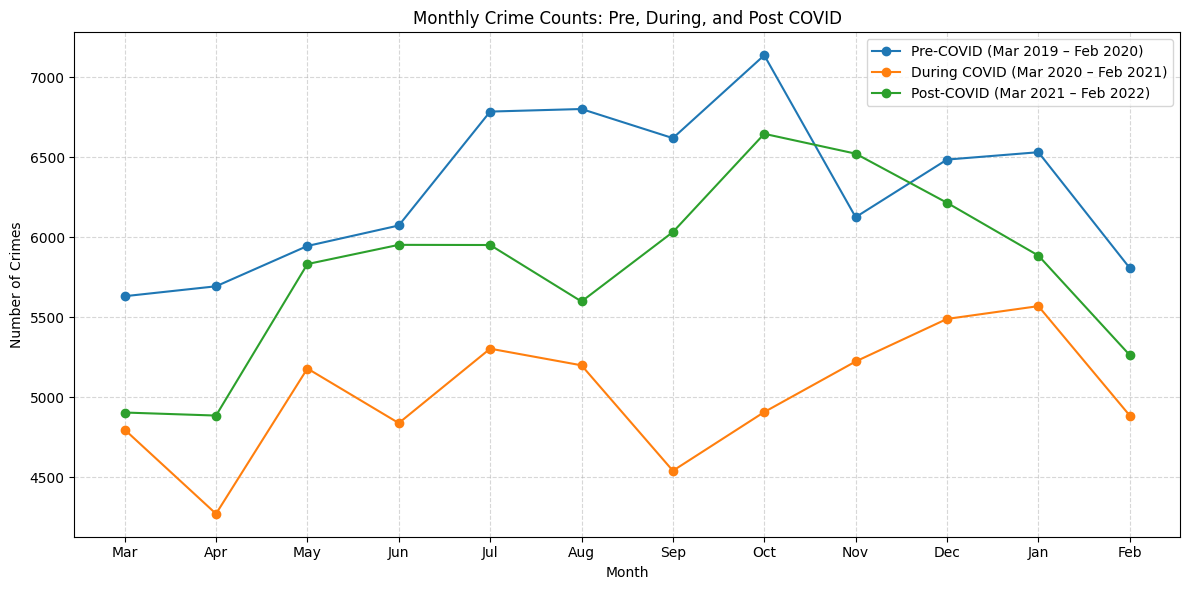

In [10]:
import matplotlib.pyplot as plt

# Count crimes per month for each period
precovid_monthly = df_precovid.groupby(df_precovid['Incident Date'].dt.month).size()
duringcovid_monthly = df_duringcovid.groupby(df_duringcovid['Incident Date'].dt.month).size()
postcovid_monthly = df_postcovid.groupby(df_postcovid['Incident Date'].dt.month).size()

# Month labels starting from March (month 3) to February (month 2)
month_order = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2]
month_labels = ['Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb']

# Reindex so all three lines follow Mar → Feb order
precovid_ordered = [precovid_monthly.get(m, 0) for m in month_order]
duringcovid_ordered = [duringcovid_monthly.get(m, 0) for m in month_order]
postcovid_ordered = [postcovid_monthly.get(m, 0) for m in month_order]

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(month_labels, precovid_ordered, marker='o', label='Pre-COVID (Mar 2019 – Feb 2020)')
ax.plot(month_labels, duringcovid_ordered, marker='o', label='During COVID (Mar 2020 – Feb 2021)')
ax.plot(month_labels, postcovid_ordered, marker='o', label='Post-COVID (Mar 2021 – Feb 2022)')

ax.set_xlabel('Month')
ax.set_ylabel('Number of Crimes')
ax.set_title('Monthly Crime Counts: Pre, During, and Post COVID')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
fig.savefig('static_crime_trends_covid.png', dpi=300)
plt.show()

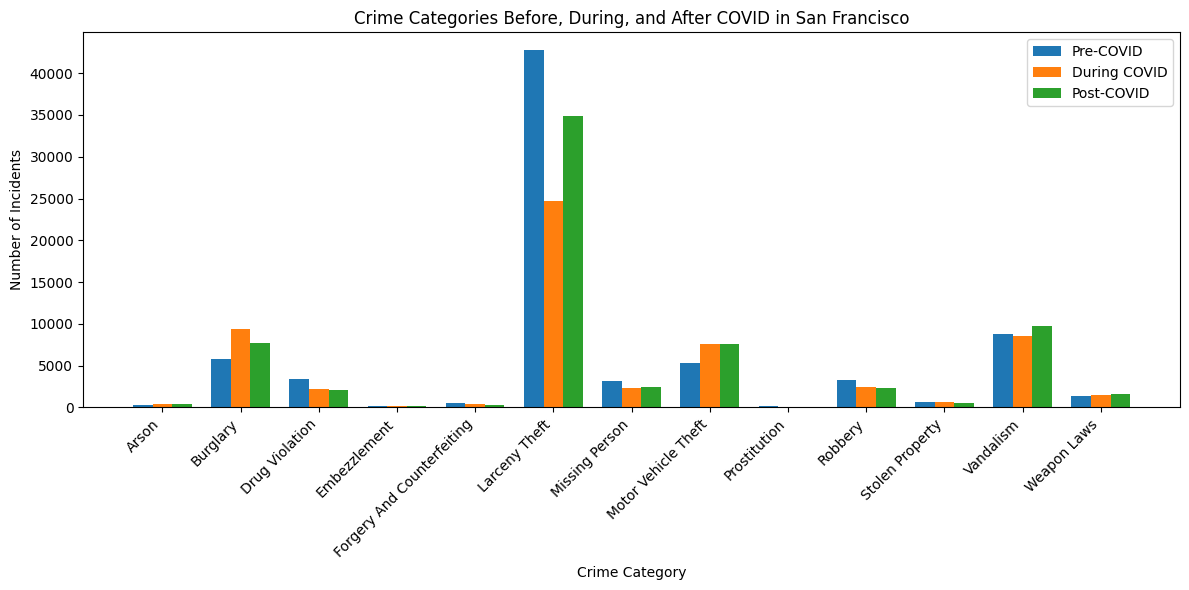

In [8]:
# Count incidents per crime type in each period
pre_counts = df_precovid['Incident Category'].value_counts()
during_counts = df_duringcovid['Incident Category'].value_counts()
post_counts = df_postcovid['Incident Category'].value_counts()

# Combine into one dataframe
crime_counts = pd.DataFrame({
    'Pre-COVID': pre_counts,
    'During COVID': during_counts,
    'Post-COVID': post_counts
}).fillna(0)

# Plot
x = np.arange(len(crime_counts.index))
width = 0.25  # smaller width to fit 3 bars
plt.close()
plt.figure(figsize=(12, 6))

plt.bar(x - width, crime_counts['Pre-COVID'], width, label='Pre-COVID')
plt.bar(x, crime_counts['During COVID'], width, label='During COVID')
plt.bar(x + width, crime_counts['Post-COVID'], width, label='Post-COVID')

plt.xticks(x, crime_counts.index, rotation=45, ha='right')
plt.xlabel('Crime Category')
plt.ylabel('Number of Incidents')
plt.title('Crime Categories Before, During, and After COVID in San Francisco')
plt.legend()

plt.tight_layout()
plt.savefig('static_crime_category_comparison.png', dpi=300)
plt.show()
# save plot

In the above plot it is noticeably burglary and motor vehicle theft that increases. If would be interesting to see the distribution of spatially whether these occur mostly in rural or urban areas.

Maybe answer the question what crimes increase during pandemics and what crimes decrease

Another reasearch question is what crimes are most correlated,

# 2. Map

In [20]:
import folium
from folium import plugins
from folium.plugins import HeatMap

In [21]:
# Redefine m every run so the state is always clean
m = folium.Map(location=[37.7749, -122.4194], zoom_start=13)

In [25]:
# 
#df_foc = df_duringcovid[(df_duringcovid['Incident Category'] == 'Burglary') | (df_duringcovid['Incident Category'] == 'Motor Vehicle Theft')]
df_foc = df_duringcovid[(df_duringcovid['Incident Category'] == 'Burglary')]
df_foc['Incident Date'] = pd.to_datetime(df_foc['Incident Date'])

C:\Users\lucas\AppData\Local\Temp\ipykernel_26016\3785136610.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_foc['Incident Date'] = pd.to_datetime(df_foc['Incident Date'])


In [26]:
# Creating a heatmap passing the lat and long of the prostitution crimes
heat_data = [[row['Latitude'], row['Longitude']] for index, row in df_foc.iterrows()]
HeatMap(heat_data, radius=10, blur=5).add_to(m)
m.save("heatmap_burglary.html")
m

# 3. Interactive Plotly Visualization